# AK70 Full Equilibrium — OLG Model with Idiosyncratic Uncertainty

Full fixed-point iteration for the AK70 OLG model.  
Wraps Steps 3–7 in a damped fixed-point loop until convergence.

> **Note:** `survival_probs.xlsx` must be in the same directory as this notebook.

In [2]:
import os
import numpy as np
import pandas as pd
import quantecon as qe
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
import time

# Jupyter runs from the notebook's own directory; verify here
NOTEBOOK_DIR = Path().resolve()
print('Working directory:', NOTEBOOK_DIR)

try:
    from numba import njit
    print('numba available — JIT compilation active')
except ImportError:
    def njit(*args, **kwargs):
        def dec(f): return f
        return dec
    print('numba not found — pure-Python fallback (slower)')

Working directory: C:\Users\russale86005\Dropbox\TEACHING\Advanced Macro Fiscal Policies\New_Course_OLG_2026\My Codes
numba available — JIT compilation active


## Step 1: Grids and Parameters

In [4]:
# Asset grids
kmin = 0.0
kmax = 20.0
na   = 501
a    = np.linspace(kmin, kmax, na)
nag  = 2 * na                          # denser grid for the distribution
ag   = np.linspace(kmin, kmax, nag)

# Earnings/income grids (for Gini statistics)
nearn  = 500
earn   = np.linspace(0, 0.01 * (nearn - 1), nearn)
income = np.linspace(0, 0.01 * (nearn - 1), nearn)

# Numerical settings
labormax = 0.6
eps      = 0.05
phi      = 0.80      # damping factor
tol      = 1e-4      # outer-loop convergence tolerance
tol1     = 1e-5      # golden-section tolerance
neg      = -1e10
nq       = 100       # max outer iterations

# Demographics
nage       = 70
nw         = 45
Rage       = 46
nr         = nage - Rage + 1   # 25 retirement periods
popgrowth0 = 0.00754

# Preferences (KPR)
beta1 = 1.011
gamma = 0.33
eta   = 2.0

# Production
ygrowth = 1.02
alpha   = 0.35
delta   = 0.083

# Fiscal
taulbar           = 0.28
tauk              = 0.36
tauc              = 0.05
replacement_ratio = 0.352
bybar             = 0.63
gybar             = 0.18

In [5]:
# Step 1.1: Demographic data
df  = pd.read_excel(NOTEBOOK_DIR / 'survival_probs.xlsx')
arr = df.to_numpy()
sp1 = arr[:, 0]          # conditional survival probs phi^s, s=1..70
ef  = arr[0:45, 1]       # age-efficiency profile, working ages only

# Step 1.3: Cohort shares
mass    = np.empty(nage)
mass[0] = 1.0
mass[1:] = np.cumprod(sp1[:nage-1] / (1.0 + popgrowth0))
mass     = mass / mass.sum()

# Step 1.4: Productivity process (Tauchen discretization)
nperm    = 2
perm     = np.array([0.57, 1.43])
lamb0    = 0.96
sigmae   = 0.045
sigmay1  = 0.38
ny       = 5

mc  = qe.markov.approximation.tauchen(n=ny, rho=lamb0, sigma=np.sqrt(sigmae),
                                       mu=0.0, n_std=1)
ye  = mc.state_values
py  = mc.P
ye1 = np.exp(ye)

muy     = np.zeros(ny)
w_grid  = ye[1] - ye[0]
muy[0]    = norm.cdf((ye[0]    + w_grid/2) / np.sqrt(sigmay1))
muy[ny-1] = 1.0 - norm.cdf((ye[ny-1] - w_grid/2) / np.sqrt(sigmay1))
for i in range(1, ny - 1):
    muy[i] = (norm.cdf((ye[i] + w_grid/2) / np.sqrt(sigmay1))
              - norm.cdf((ye[i] - w_grid/2) / np.sqrt(sigmay1)))

print('Demographics and productivity process loaded.')

Demographics and productivity process loaded.


## Helper Functions

In [7]:
def ginid(x, gy, ng):
    x     = np.maximum(x, 0.0)
    xmean = np.dot(x, gy)
    if xmean == 0.0:
        return 0.0
    cumF      = np.cumsum(gy * (x / xmean))
    F_prev    = np.empty_like(cumF)
    F_prev[0] = 0.0
    F_prev[1:] = cumF[:-1]
    return 1.0 - np.dot(cumF + F_prev, gy)

def wage(k, l):
    return (1 - alpha) * k**alpha * l**(-alpha)

def interest(k, l):
    return alpha * k**(alpha - 1) * l**(1 - alpha)

def production(k, l):
    return k**alpha * l**(1 - alpha)

def u(c, l):
    if eta == 1:
        return gamma * np.log(c) + (1 - gamma) * np.log(1 - l)
    return (c**(gamma*(1-eta)) * (1-l)**((1-gamma)*(1-eta))) / (1 - eta)

## Numba-compiled VFI Helpers

These functions are compiled on first call (JIT). Expect a short delay the first iteration.

In [9]:
@njit
def _ret_val(x, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vn):
    c = (a0_rb - ygrowth * x) / (1.0 + tauc)
    if c <= 0.0:
        return neg
    if eta == 1.0:
        u = gamma * np.log(c)
    else:
        u = c ** (gamma * (1.0 - eta)) / (1.0 - eta)
    return u + disc * np.interp(x, ag, vn)

@njit
def _gss_ret(ay, by, cy, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, tol, ag, vn):
    R = 0.61803399; r2 = 1.0 - R
    x0, x3 = ay, cy
    if abs(cy - by) <= abs(by - ay):
        x1 = by; x2 = by + r2 * (cy - by)
    else:
        x2 = by; x1 = by - r2 * (by - ay)
    f1 = -_ret_val(x1, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vn)
    f2 = -_ret_val(x2, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vn)
    while abs(x3 - x0) > tol * (abs(x1) + abs(x2)):
        if f2 < f1:
            x0 = x1; x1 = x2; x2 = R * x1 + r2 * x3; f1 = f2
            f2 = -_ret_val(x2, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vn)
        else:
            x3 = x2; x2 = x1; x1 = R * x2 + r2 * x0; f2 = f1
            f1 = -_ret_val(x1, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vn)
    return x1 if f1 <= f2 else x2

@njit
def _vfi_ret_inner(ag, na, vr_next, rb1, pen_tr, ygrowth, tauc,
                   disc, gamma, eta, neg, tol1, eps):
    aropt = np.empty(na); cropt = np.empty(na); vr_out = np.empty(na)
    da = ag[1] - ag[0]
    for ia in range(na):
        a0_rb = rb1 * ag[ia] + pen_tr
        ax, bx, cx = 0.0, -1.0, -2.0; v0 = neg; j = -1
        while ax > bx or bx > cx:
            j += 1
            v1 = _ret_val(ag[j], a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next)
            if v1 > v0:
                ax = ag[0] if j == 0 else ag[j - 1]; bx = ag[j]; v0 = v1
            else:
                cx = ag[j]
            if j == na - 1:
                ax = ag[na - 2]; bx = ag[na - 1]; cx = ag[na - 1]
        if ax == bx:
            bx2 = ax + da * eps
            if (_ret_val(ax,  a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next) >
                    _ret_val(bx2, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next)):
                k1 = ag[0]
            else:
                k1 = _gss_ret(ax, bx2, ag[1], a0_rb, ygrowth, tauc, disc,
                               gamma, eta, neg, tol1, ag, vr_next)
        elif bx == cx:
            bx2 = ag[na - 1] - eps * (ag[na - 1] - ag[na - 2])
            if (_ret_val(ag[na - 1], a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next) >
                    _ret_val(bx2, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next)):
                k1 = ag[na - 1]
            else:
                k1 = _gss_ret(ag[na - 2], bx2, ag[na - 1], a0_rb, ygrowth, tauc, disc,
                               gamma, eta, neg, tol1, ag, vr_next)
        else:
            k1 = _gss_ret(ax, bx, cx, a0_rb, ygrowth, tauc, disc,
                           gamma, eta, neg, tol1, ag, vr_next)
        aropt[ia] = k1
        cropt[ia] = (a0_rb - ygrowth * k1) / (1.0 + tauc)
        vr_out[ia] = _ret_val(k1, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next)
    return aropt, cropt, vr_out


@njit
def _wk_val(x, rb1_a0_tr, denom, ygrowth, tauc, labormax,
            disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age):
    labor = gamma - (rb1_a0_tr - ygrowth * x) * (1.0 - gamma) / denom
    if labor < 0.0:      labor = 0.0
    if labor > labormax: labor = labormax
    c = (rb1_a0_tr + denom * labor - ygrowth * x) / (1.0 + tauc)
    if c <= 0.0:
        return neg
    if eta == 1.0:
        u = gamma * np.log(c) + (1.0 - gamma) * np.log(1.0 - labor)
    else:
        u = (c**(gamma*(1.0-eta)) * (1.0-labor)**((1.0-gamma)*(1.0-eta))) / (1.0-eta)
    if last_age:
        return u + disc * np.interp(x, ag, vr0)
    v_exp = 0.0
    for iy1 in range(ny):
        v_exp += py_row[iy1] * np.interp(x, ag, vw_T[iy1])
    return u + disc * v_exp

@njit
def _gss_wk(ay, by, cy, rb1_a0_tr, denom, ygrowth, tauc, labormax,
            disc, gamma, eta, neg, tol, ag, vr0, vw_T, ny, py_row, last_age):
    R = 0.61803399; r2 = 1.0 - R
    x0, x3 = ay, cy
    if abs(cy - by) <= abs(by - ay):
        x1 = by; x2 = by + r2 * (cy - by)
    else:
        x2 = by; x1 = by - r2 * (by - ay)
    f1 = -_wk_val(x1, rb1_a0_tr, denom, ygrowth, tauc, labormax,
                  disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
    f2 = -_wk_val(x2, rb1_a0_tr, denom, ygrowth, tauc, labormax,
                  disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
    while abs(x3 - x0) > tol * (abs(x1) + abs(x2)):
        if f2 < f1:
            x0 = x1; x1 = x2; x2 = R * x1 + r2 * x3; f1 = f2
            f2 = -_wk_val(x2, rb1_a0_tr, denom, ygrowth, tauc, labormax,
                          disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
        else:
            x3 = x2; x2 = x1; x1 = R * x2 + r2 * x0; f2 = f1
            f1 = -_wk_val(x1, rb1_a0_tr, denom, ygrowth, tauc, labormax,
                          disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
    return x1 if f1 <= f2 else x2

@njit
def _vfi_wk_inner(ag, na, ny, rb1, trbar, w_eff, taun_taup, ygrowth, tauc, labormax,
                  disc, gamma, eta, neg, tol1, eps, py_row, vw_T, vr0, last_age):
    awopt_c = np.empty(na); lopt_c  = np.empty(na)
    cwopt_c = np.empty(na); vw_c    = np.empty(na)
    da    = ag[1] - ag[0]
    denom = (1.0 - taun_taup) * w_eff
    j0 = -1
    for ia in range(na):
        rb1_a0_tr = rb1 * ag[ia] + trbar
        ax, bx, cx = 0.0, -1.0, -2.0; v0 = neg; j = j0
        while ax > bx or bx > cx:
            j += 1
            v1 = _wk_val(ag[j], rb1_a0_tr, denom, ygrowth, tauc, labormax,
                         disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
            if v1 > v0:
                j0 = max(-1, j - 2)
                ax = ag[0] if j == 0 else ag[j - 1]; bx = ag[j]; v0 = v1
            else:
                cx = ag[j]
            if j == na - 1:
                ax = ag[na - 2]; bx = ag[na - 1]; cx = ag[na - 1]
        if ax == bx:
            bx2 = ax + da * eps
            if (_wk_val(ax,  rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta,
                        neg, ag, vr0, vw_T, ny, py_row, last_age) >
                    _wk_val(bx2, rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta,
                            neg, ag, vr0, vw_T, ny, py_row, last_age)):
                k1 = ag[0]
            else:
                k1 = _gss_wk(ax, bx2, ag[1], rb1_a0_tr, denom, ygrowth, tauc, labormax,
                             disc, gamma, eta, neg, tol1, ag, vr0, vw_T, ny, py_row, last_age)
        elif bx == cx:
            bx2 = ag[na - 1] - eps * (ag[na - 1] - ag[na - 2])
            if (_wk_val(ag[na - 1], rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta,
                        neg, ag, vr0, vw_T, ny, py_row, last_age) >
                    _wk_val(bx2, rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta,
                            neg, ag, vr0, vw_T, ny, py_row, last_age)):
                k1 = ag[na - 1]
            else:
                k1 = _gss_wk(ag[na - 2], bx2, ag[na - 1], rb1_a0_tr, denom, ygrowth, tauc,
                             labormax, disc, gamma, eta, neg, tol1, ag, vr0, vw_T, ny,
                             py_row, last_age)
        else:
            k1 = _gss_wk(ax, bx, cx, rb1_a0_tr, denom, ygrowth, tauc, labormax,
                         disc, gamma, eta, neg, tol1, ag, vr0, vw_T, ny, py_row, last_age)
        awopt_c[ia] = k1
        labor = gamma - (rb1_a0_tr - ygrowth * k1) * (1.0 - gamma) / denom
        if labor < 0.0:      labor = 0.0
        if labor > labormax: labor = labormax
        lopt_c[ia]  = labor
        cwopt_c[ia] = (rb1_a0_tr + denom * labor - ygrowth * k1) / (1.0 + tauc)
        vw_c[ia]    = _wk_val(k1, rb1_a0_tr, denom, ygrowth, tauc, labormax,
                              disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
    return awopt_c, lopt_c, cwopt_c, vw_c

## Step 2: Initial Guesses

In [11]:
rbar       = 0.03
nbar       = 0.30
mean_labor = 0.30
kbar       = (alpha / (rbar + delta))**(1.0 / (1.0 - alpha)) * nbar
omega      = kbar * 1.2
trbar      = 0.01

w_p   = wage(kbar, nbar)
pen   = replacement_ratio * w_p * mean_labor
taup  = pen * mass[nw:nage].sum() / (w_p * nbar)
taun  = taulbar - taup

print(f'Initial guesses:')
print(f'  kbar={kbar:.4f}  nbar={nbar:.4f}  r={interest(kbar,nbar):.4f}  w={w_p:.4f}')
print(f'  pen={pen:.4f}  taup={taup:.4f}  taun={taun:.4f}  trbar={trbar:.4f}')
print(f'\nStarting outer loop (tol={tol}, max_iter={nq}, phi={phi}) ...')

Initial guesses:
  kbar=1.7080  nbar=0.3000  r=0.1130  w=1.1948
  pen=0.1262  taup=0.0773  taun=0.2027  trbar=0.0100

Starting outer loop (tol=0.0001, max_iter=100, phi=0.8) ...


## Outer Fixed-Point Loop (Steps 3–7)

This is the main computation. Each iteration solves the VFI, simulates the distribution, and updates aggregate prices until convergence.

In [13]:
t_start      = time.time()
diff         = 1.0
it           = 0
conv_history = []

while diff > tol and it < nq:
    it   += 1
    t_it  = time.time()

    # Step 3: Factor prices
    w_p   = wage(kbar, nbar)
    r     = interest(kbar, nbar)
    rb    = (1.0 - tauk) * (r - delta)
    rb1   = 1.0 + rb
    pen   = replacement_ratio * w_p * mean_labor
    taun  = taulbar - taup
    pen_tr = pen + trbar

    # Step 4a: Retiree VFI (backward induction)
    vr    = np.zeros((na, nr))
    aropt = np.zeros((na, nr))
    cropt = np.zeros((na, nr))

    for ia in range(na):
        c = (rb1 * a[ia] + pen_tr) / (1.0 + tauc)
        vr[ia, nr-1]    = u(c, 0)
        cropt[ia, nr-1] = c
        aropt[ia, nr-1] = 0.0

    for iage in range(nr - 2, -1, -1):
        disc    = ygrowth**(gamma * (1 - eta)) * sp1[nw + iage] * beta1
        vr_next = np.ascontiguousarray(vr[:, iage + 1])
        aropt_c, cropt_c, vr_c = _vfi_ret_inner(
            a, na, vr_next, rb1, pen_tr, ygrowth, tauc,
            disc, gamma, eta, neg, tol1, eps)
        aropt[:, iage] = aropt_c
        cropt[:, iage] = cropt_c
        vr[:, iage]    = vr_c

    # Step 4b: Worker VFI (backward induction)
    vw    = np.zeros((na, ny, nperm, nw))
    awopt = np.zeros((na, ny, nperm, nw))
    lopt  = np.zeros((na, ny, nperm, nw))
    cwopt = np.zeros((na, ny, nperm, nw))
    vr0   = np.ascontiguousarray(vr[:, 0])

    for iage in range(nw - 1, -1, -1):
        last_age  = (iage == nw - 1)
        disc_base = ygrowth**(gamma * (1 - eta)) * sp1[iage] * beta1
        for iperm in range(nperm):
            for iy in range(ny):
                w_eff  = w_p * ef[iage] * perm[iperm] * ye1[iy]
                py_row = np.ascontiguousarray(py[iy])
                vw_T   = (np.zeros((ny, na)) if last_age
                          else np.ascontiguousarray(vw[:, :, iperm, iage + 1].T))
                awopt_c, lopt_c, cwopt_c, vw_c = _vfi_wk_inner(
                    a, na, ny, rb1, trbar, w_eff, taun + taup, ygrowth, tauc,
                    labormax, disc_base, gamma, eta, neg, tol1, eps,
                    py_row, vw_T, vr0, last_age)
                awopt[:, iy, iperm, iage] = awopt_c
                lopt[:,  iy, iperm, iage] = lopt_c
                cwopt[:, iy, iperm, iage] = cwopt_c
                vw[:,    iy, iperm, iage] = vw_c

    # Step 5: Forward simulation of the cross-sectional measure
    gkw          = np.zeros((nag, ny, nperm, nw))
    gkr          = np.zeros((nag, nr))
    kgen         = np.zeros(nage)
    gearn        = np.zeros(nearn)
    gincome_dist = np.zeros(nearn)
    gk           = np.zeros((nag, nw))

    # Newborns: zero wealth, distributed over (perm, theta)
    gk[0, 0] = mass[0]
    for iy in range(ny):
        gkw[0, iy, 0, 0] = 0.5 * muy[iy] * mass[0]
        gkw[0, iy, 1, 0] = 0.5 * muy[iy] * mass[0]

    # 5a: Roll workers forward, s = 1 .. T^W - 1
    for iage in range(nw - 1):
        for iperm in range(nperm):
            for iy in range(ny):
                f_arr = gkw[:, iy, iperm, iage]
                if f_arr.sum() == 0.0:
                    continue
                k1_arr    = np.interp(ag, a, awopt[:, iy, iperm, iage])
                labor_arr = np.interp(ag, a, lopt[:,  iy, iperm, iage])

                # earnings distribution
                x_arr = perm[iperm] * ye1[iy] * ef[iage] * w_p * labor_arr
                w_f   = f_arr / mass[0:nw].sum()
                m_lo  = x_arr <= 0; m_hi = x_arr >= earn[-1]; m_mid = ~m_lo & ~m_hi
                if m_mid.any():
                    j0_e = np.clip(np.searchsorted(earn, x_arr[m_mid], side='right'), 1, nearn-1)
                    n0_e = np.clip((x_arr[m_mid] - earn[j0_e-1])
                                   / (earn[j0_e] - earn[j0_e-1]), 0, 1)
                    np.add.at(gearn, j0_e-1, (1-n0_e) * w_f[m_mid])
                    np.add.at(gearn, j0_e,       n0_e  * w_f[m_mid])
                gearn[0] += w_f[m_lo].sum(); gearn[nearn-1] += w_f[m_hi].sum()

                # income distribution
                y_arr  = x_arr + (r - delta) * ag
                m_lo_y = y_arr < 0; m_hi_y = y_arr >= income[-1]; m_md_y = ~m_lo_y & ~m_hi_y
                if m_md_y.any():
                    j0_y = np.clip(np.searchsorted(income, y_arr[m_md_y], side='right'), 1, nearn-1)
                    n0_y = np.clip((y_arr[m_md_y] - income[j0_y-1])
                                   / (income[j0_y] - income[j0_y-1]), 0, 1)
                    np.add.at(gincome_dist, j0_y-1, (1-n0_y) * f_arr[m_md_y])
                    np.add.at(gincome_dist, j0_y,       n0_y  * f_arr[m_md_y])
                gincome_dist[0] += f_arr[m_lo_y].sum()
                gincome_dist[nearn-1] += f_arr[m_hi_y].sum()

                # law of motion for the wealth measure
                surv   = sp1[iage] / (1.0 + popgrowth0)
                m_lo_k = k1_arr <= kmin; m_hi_k = k1_arr >= kmax; m_md_k = ~m_lo_k & ~m_hi_k
                if m_md_k.any():
                    j0_k = np.clip(np.searchsorted(ag, k1_arr[m_md_k], side='right'), 1, nag-1)
                    n0_k = np.clip((k1_arr[m_md_k] - ag[j0_k-1])
                                   / (ag[j0_k] - ag[j0_k-1]), 0, 1)
                    f_md = f_arr[m_md_k] * surv
                    for iy1 in range(ny):
                        p = py[iy, iy1]
                        np.add.at(gkw[:, iy1, iperm, iage+1], j0_k-1, (1-n0_k) * p * f_md)
                        np.add.at(gkw[:, iy1, iperm, iage+1], j0_k,       n0_k  * p * f_md)
                for iy1 in range(ny):
                    p = py[iy, iy1]
                    gkw[0,     iy1, iperm, iage+1] += p * surv * f_arr[m_lo_k].sum()
                    gkw[nag-1, iy1, iperm, iage+1] += p * surv * f_arr[m_hi_k].sum()

        for iag2 in range(nag):
            gk[iag2, iage+1] = gkw[iag2, :, :, iage+1].sum()
        kgen[iage+1] = np.dot(gk[:, iage+1], ag)

    # 5b: Transition from last working age to first retirement age
    iage = nw - 1
    for iperm in range(nperm):
        for iy in range(ny):
            f_arr     = gkw[:, iy, iperm, iage]
            k1_arr    = np.interp(ag, a, awopt[:, iy, iperm, iage])
            labor_arr = np.interp(ag, a, lopt[:,  iy, iperm, iage])

            x_arr = perm[iperm] * ye1[iy] * ef[iage] * w_p * labor_arr
            w_f   = f_arr / mass[0:nw].sum()
            m_lo  = x_arr <= 0; m_hi = x_arr >= earn[-1]; m_mid = ~m_lo & ~m_hi
            if m_mid.any():
                j0_e = np.clip(np.searchsorted(earn, x_arr[m_mid], side='right'), 1, nearn-1)
                n0_e = np.clip((x_arr[m_mid]-earn[j0_e-1])/(earn[j0_e]-earn[j0_e-1]), 0, 1)
                np.add.at(gearn, j0_e-1, (1-n0_e)*w_f[m_mid])
                np.add.at(gearn, j0_e,       n0_e *w_f[m_mid])
            gearn[0] += w_f[m_lo].sum(); gearn[nearn-1] += w_f[m_hi].sum()

            y_arr  = x_arr + (r-delta)*ag
            m_lo_y = y_arr < 0; m_hi_y = y_arr >= income[-1]; m_md_y = ~m_lo_y & ~m_hi_y
            if m_md_y.any():
                j0_y = np.clip(np.searchsorted(income, y_arr[m_md_y], side='right'), 1, nearn-1)
                n0_y = np.clip((y_arr[m_md_y]-income[j0_y-1])/(income[j0_y]-income[j0_y-1]), 0, 1)
                np.add.at(gincome_dist, j0_y-1, (1-n0_y)*f_arr[m_md_y])
                np.add.at(gincome_dist, j0_y,       n0_y *f_arr[m_md_y])
            gincome_dist[0] += f_arr[m_lo_y].sum()
            gincome_dist[nearn-1] += f_arr[m_hi_y].sum()

            surv   = sp1[iage] / (1.0 + popgrowth0)
            m_lo_k = k1_arr <= kmin; m_hi_k = k1_arr >= kmax; m_md_k = ~m_lo_k & ~m_hi_k
            if m_md_k.any():
                j0_k = np.clip(np.searchsorted(ag, k1_arr[m_md_k], side='right'), 1, nag-1)
                n0_k = np.clip((k1_arr[m_md_k]-ag[j0_k-1])/(ag[j0_k]-ag[j0_k-1]), 0, 1)
                f_md = f_arr[m_md_k] * surv
                np.add.at(gkr[:, 0], j0_k-1, (1-n0_k)*f_md)
                np.add.at(gkr[:, 0], j0_k,       n0_k *f_md)
            gkr[0,     0] += surv * f_arr[m_lo_k].sum()
            gkr[nag-1, 0] += surv * f_arr[m_hi_k].sum()

    kgen[nw] = np.dot(gkr[:, 0], ag)

    # 5c: Roll retirees forward, s = T^W+1 .. T-1
    for iage in range(nr - 1):
        f_arr  = gkr[:, iage]
        k1_arr = np.interp(ag, a, aropt[:, iage])

        y_arr  = pen + (r - delta) * ag
        m_lo_y = y_arr < 0; m_hi_y = y_arr >= income[-1]; m_md_y = ~m_lo_y & ~m_hi_y
        if m_md_y.any():
            j0_y = np.clip(np.searchsorted(income, y_arr[m_md_y], side='right'), 1, nearn-1)
            n0_y = np.clip((y_arr[m_md_y]-income[j0_y-1])/(income[j0_y]-income[j0_y-1]), 0, 1)
            np.add.at(gincome_dist, j0_y-1, (1-n0_y)*f_arr[m_md_y])
            np.add.at(gincome_dist, j0_y,       n0_y *f_arr[m_md_y])
        gincome_dist[0] += f_arr[m_lo_y].sum()
        gincome_dist[nearn-1] += f_arr[m_hi_y].sum()

        surv   = sp1[iage + nw] / (1.0 + popgrowth0)
        m_lo_k = k1_arr <= kmin; m_hi_k = k1_arr >= kmax; m_md_k = ~m_lo_k & ~m_hi_k
        if m_md_k.any():
            j0_k = np.clip(np.searchsorted(ag, k1_arr[m_md_k], side='right'), 1, nag-1)
            n0_k = np.clip((k1_arr[m_md_k]-ag[j0_k-1])/(ag[j0_k]-ag[j0_k-1]), 0, 1)
            f_md = f_arr[m_md_k] * surv
            np.add.at(gkr[:, iage+1], j0_k-1, (1-n0_k)*f_md)
            np.add.at(gkr[:, iage+1], j0_k,       n0_k *f_md)
        gkr[0,     iage+1] += surv * f_arr[m_lo_k].sum()
        gkr[nag-1, iage+1] += surv * f_arr[m_hi_k].sum()
        kgen[iage + nw + 1] = np.dot(gkr[:, iage+1], ag)

    # Step 6: Aggregate variables
    omeganew     = kgen.sum() / mass.sum()
    ybar         = production(kbar, nbar)
    debt         = bybar * ybar
    gbar_val     = gybar * ybar
    knew         = omeganew - debt

    nnew       = 0.0
    bequests   = 0.0
    bigc       = 0.0
    mean_labor = 0.0
    cgen       = np.zeros(nage)
    lgen       = np.zeros(nw)
    gwealth    = np.zeros(nag)
    mass_wk    = mass[0:nw].sum()

    for iage in range(nw):
        for iperm in range(nperm):
            for iy in range(ny):
                f_arr = gkw[:, iy, iperm, iage]
                if f_arr.sum() == 0.0:
                    continue
                k1_arr    = np.interp(ag, a, awopt[:, iy, iperm, iage])
                c_arr     = np.interp(ag, a, cwopt[:, iy, iperm, iage])
                labor_arr = np.interp(ag, a, lopt[:,  iy, iperm, iage])
                eff        = ef[iage] * ye1[iy] * perm[iperm]
                nnew       += eff * np.dot(labor_arr, f_arr)
                mean_labor += np.dot(labor_arr, f_arr) / mass_wk
                cgen[iage] += np.dot(c_arr,     f_arr) / mass[iage]
                lgen[iage] += np.dot(labor_arr, f_arr) / mass[iage]
                beq_f       = rb1 * (1.0 - sp1[iage]) / (1.0 + popgrowth0)
                bequests   += beq_f * np.dot(k1_arr, f_arr)
                bigc       += np.dot(c_arr, f_arr)
                gwealth    += f_arr

    for iage in range(nr):
        f_arr = gkr[:, iage]
        if f_arr.sum() == 0.0:
            continue
        k1_arr = np.interp(ag, a, aropt[:, iage])
        c_arr  = np.interp(ag, a, cropt[:, iage])
        beq_f  = rb1 * (1.0 - sp1[iage + nw]) / (1.0 + popgrowth0)
        bequests        += beq_f * np.dot(k1_arr, f_arr)
        bigc            += np.dot(c_arr, f_arr)
        gwealth         += f_arr
        cgen[nw + iage] += np.dot(c_arr, f_arr) / mass[nw + iage]

    # Step 7: Compute implied new values, check convergence, damp
    taxes       = taun * w_p * nbar + tauk * (r - delta) * kbar + tauc * bigc
    transfernew = (taxes + bequests
                   + debt * ((1 + popgrowth0) * ygrowth - rb1)
                   - gbar_val)

    pennew  = replacement_ratio * w_p * mean_labor
    taupnew = pennew * mass[nw:nage].sum() / (w_p * nnew)

    diff = max(abs(knew - kbar), abs(nnew - nbar),
               abs(taupnew - taup), abs(transfernew - trbar))
    conv_history.append(diff)

    # damped update
    kbar  = phi * kbar  + (1 - phi) * knew
    nbar  = phi * nbar  + (1 - phi) * nnew
    taup  = phi * taup  + (1 - phi) * taupnew
    taun  = taulbar - taup
    trbar = phi * trbar + (1 - phi) * transfernew
    omega = phi * omega + (1 - phi) * omeganew

    elapsed = time.time() - t_it
    print(f'it={it:3d}  diff={diff:.2e}  K={kbar:.4f}  L={nbar:.4f}'
          f'  taup={taup:.4f}  Tr={trbar:.4f}  ({elapsed:.1f}s)')

it=  1  diff=5.01e-01  K=1.6079  L=0.3045  taup=0.0775  Tr=0.0122  (38.5s)
it=  2  diff=3.20e-01  K=1.5438  L=0.3074  taup=0.0776  Tr=0.0143  (27.2s)
it=  3  diff=1.48e-01  K=1.5142  L=0.3095  taup=0.0776  Tr=0.0163  (27.6s)
it=  4  diff=6.30e-02  K=1.5016  L=0.3109  taup=0.0775  Tr=0.0181  (28.2s)
it=  5  diff=2.32e-02  K=1.4969  L=0.3117  taup=0.0774  Tr=0.0196  (27.8s)
it=  6  diff=6.96e-03  K=1.4955  L=0.3122  taup=0.0772  Tr=0.0209  (23.2s)
it=  7  diff=5.17e-03  K=1.4953  L=0.3124  taup=0.0771  Tr=0.0219  (22.9s)
it=  8  diff=4.22e-03  K=1.4952  L=0.3124  taup=0.0770  Tr=0.0228  (22.8s)
it=  9  diff=3.43e-03  K=1.4950  L=0.3123  taup=0.0768  Tr=0.0234  (23.0s)
it= 10  diff=2.79e-03  K=1.4946  L=0.3122  taup=0.0767  Tr=0.0240  (22.7s)
it= 11  diff=2.57e-03  K=1.4941  L=0.3120  taup=0.0766  Tr=0.0245  (23.2s)
it= 12  diff=3.09e-03  K=1.4935  L=0.3118  taup=0.0765  Tr=0.0248  (23.9s)
it= 13  diff=3.36e-03  K=1.4928  L=0.3115  taup=0.0764  Tr=0.0251  (23.7s)
it= 14  diff=3.45e-03  K=

## Convergence Report & Equilibrium Statistics

In [15]:
total_time = time.time() - t_start
if diff <= tol:
    print(f'Converged in {it} iterations  ({total_time/60:.1f} min total)')
else:
    print(f'Did NOT converge after {it} iterations  ({total_time/60:.1f} min). '
          f'Last diff={diff:.2e}')

gk_full = np.c_[gk, gkr]
gk_full = gk_full / gk_full.sum()
gk1     = gk_full.sum(axis=1)

gini_wealth   = ginid(ag,     gk1,          nag)
gini_earnings = ginid(earn,   gearn,         nearn)
gini_income   = ginid(income, gincome_dist,  nearn)

print(f'\nEquilibrium statistics:')
print(f'  K      = {kbar:.4f}   L      = {nbar:.4f}')
print(f'  r      = {r:.4f}    w      = {w_p:.4f}')
print(f'  K/Y    = {kbar/production(kbar,nbar):.4f}')
print(f'  tau^p  = {taup:.4f}   tau^n  = {taun:.4f}')
print(f'  Tr     = {trbar:.4f}   pen    = {pen:.4f}')
print(f'  Gini wealth   = {gini_wealth:.4f}   (target ~0.66)')
print(f'  Gini earnings = {gini_earnings:.4f}   (target ~0.51)')
print(f'  Gini income   = {gini_income:.4f}')

Converged in 41 iterations  (16.4 min total)

Equilibrium statistics:
  K      = 1.4859   L      = 0.3096
  r      = 0.1263    w      = 1.1255
  K/Y    = 2.7719
  tau^p  = 0.0759   tau^n  = 0.2041
  Tr     = 0.0265   pen    = 0.1204
  Gini wealth   = 0.6644   (target ~0.66)
  Gini earnings = 0.5052   (target ~0.51)
  Gini income   = 0.4999


## Plots

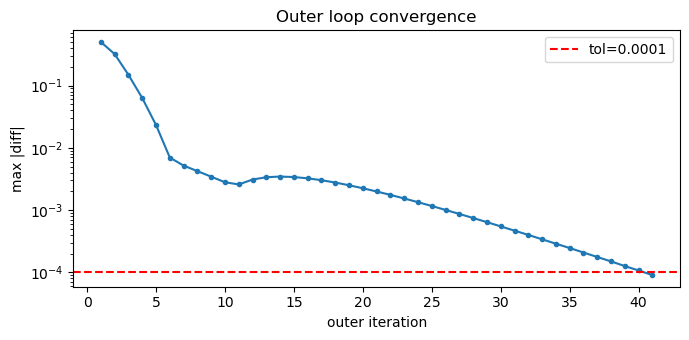

In [17]:
# Convergence path
plt.figure(figsize=(7, 3.5))
plt.semilogy(range(1, len(conv_history)+1), conv_history, marker='o', markersize=3)
plt.axhline(tol, color='r', linestyle='--', label=f'tol={tol}')
plt.xlabel('outer iteration'); plt.ylabel('max |diff|')
plt.title('Outer loop convergence'); plt.legend(); plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'AK70_convergence.pdf', bbox_inches='tight')
plt.show()

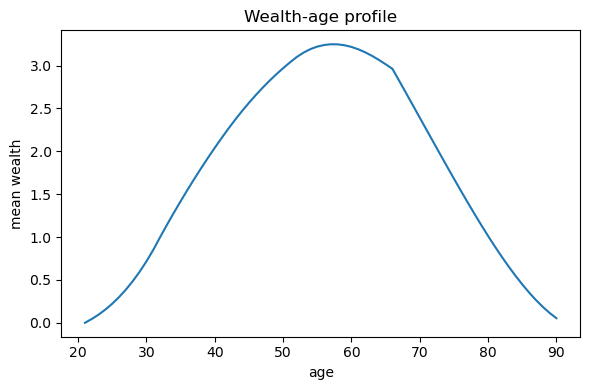

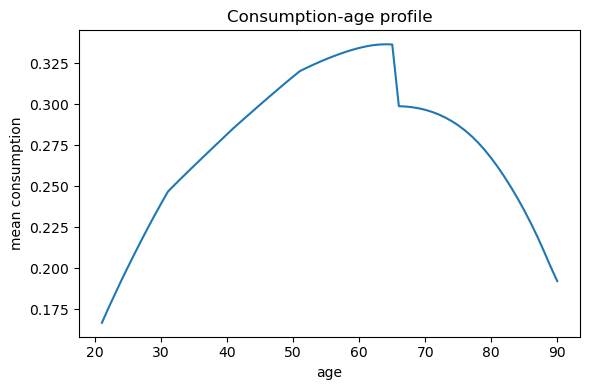

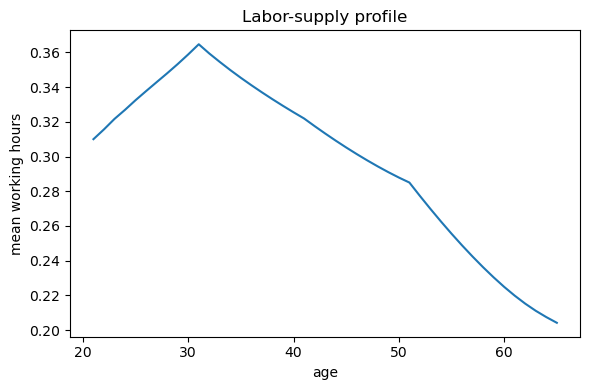

In [32]:
# Life-cycle profiles — separate figures

# 1. Wealth-age profile
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(21, 91), kgen / mass)
ax.set_xlabel('age')
ax.set_ylabel('mean wealth')
ax.set_title('Wealth-age profile')
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'AK70_wealth.pdf', bbox_inches='tight')
plt.show()

# 2. Consumption-age profile
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(21, 91), cgen)
ax.set_xlabel('age')
ax.set_ylabel('mean consumption')
ax.set_title('Consumption-age profile')
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'AK70_consumption.pdf', bbox_inches='tight')
plt.show()

# 3. Labor-supply profile
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(21, 66), lgen)
ax.set_xlabel('age')
ax.set_ylabel('mean working hours')
ax.set_title('Labor-supply profile')
plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'AK70_labor.pdf', bbox_inches='tight')
plt.show()

## Save Results

In [20]:
np.savez(NOTEBOOK_DIR / 'AK70_equilibrium.npz',
         vw=vw, vr=vr,
         awopt=awopt, aropt=aropt,
         cwopt=cwopt, cropt=cropt, lopt=lopt,
         gkw=gkw, gkr=gkr,
         cgen=cgen, lgen=lgen, kgen=kgen,
         earn=earn, gearn=gearn,
         gwealth=gwealth, ag=ag,
         kbar=np.array(kbar), nbar=np.array(nbar),
         taup=np.array(taup), taun=np.array(taun),
         trbar=np.array(trbar), r=np.array(r), w=np.array(w_p),
         gini_wealth=np.array(gini_wealth),
         gini_earnings=np.array(gini_earnings),
         gini_income=np.array(gini_income),
         conv_history=np.array(conv_history))

print('Results saved to AK70_equilibrium.npz')
print('Figures saved to AK70_convergence.pdf and AK70_lifecycle.pdf')

Results saved to AK70_equilibrium.npz
Figures saved to AK70_convergence.pdf and AK70_lifecycle.pdf
